In [33]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns

In [34]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "insurance.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mirichoi0218/insurance",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_154/1773325154.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'insurance' dataset.
First 5 records:    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X = df.drop(columns = ['charges'])
y = df['charges']

X = pd.get_dummies(X,columns=['region'],drop_first=True,dtype=int)

X['sex'] = X['sex'].map({'female':1,'male':0})
X['smoker'] = X['smoker'].map({'yes':1,'no':0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn import linear_model

MSE for 0.001 : 20922599.87103596
MSE for 0.1 : 20921803.698431376
MSE for 1 : 20914832.63508914
MSE for 2 : 20908106.779954515
MSE for 5 : 20890881.000633497
MSE for 10 : 20872844.794796683
MSE for 20 : 20877828.53237883
MSE for 40 : 21046489.29389078
MSE for 50 : 21196929.8696089
MSE for 100 : 22423172.686023254


<Axes: >

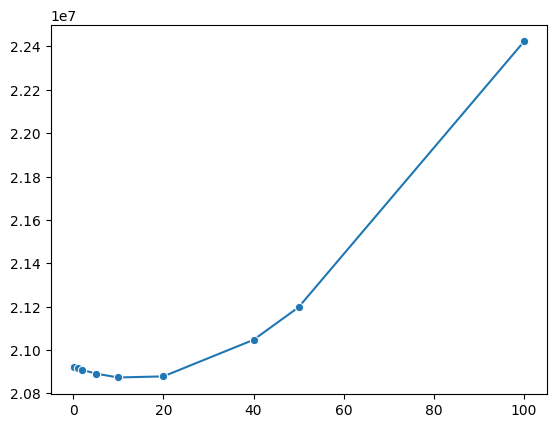

In [ ]:
# layman technique - Straight approach usign a loop; although Cross validation is being used to find the perfect value of alpha.

alphas = [0.001,0.1,1,2,5,10,20,40,50,100]

mses = []

for a in alphas:
  lasso_model = linear_model.Lasso(alpha=a)
  lasso_model.fit(X_train, y_train)
  y_pred = lasso_model.predict(X_test)
  mse = mean_squared_error(y_test,y_pred)
  print(f"MSE for {a} :",mse)
  mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker='o')

In [ ]:
#LassoCV


from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
a = [0.001,0.1,1,2,5,10,20,40,50,100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter = 500,
    random_state=42
)

lasso_cv_model.fit(X_train,y_train)
print("Best alpha :",lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("Final MSE :",mse)
r2 = r2_score(y_test,y_pred)
print("Final R2 :",r2)